In [311]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
outlier_handler = OutlierHandling()

In [284]:
mydata = pd.read_csv(r'data\BankChurners.csv')

In [285]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [286]:
columns_list = mydata.columns.tolist()
print(columns_list)

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [287]:
df = mydata.drop(columns=columns_list[-2:])
df = df.drop(columns='CLIENTNUM')

In [288]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [289]:
df['Attrition_Flag'].unique().tolist()

['Existing Customer', 'Attrited Customer']

In [290]:
df.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

<Axes: >

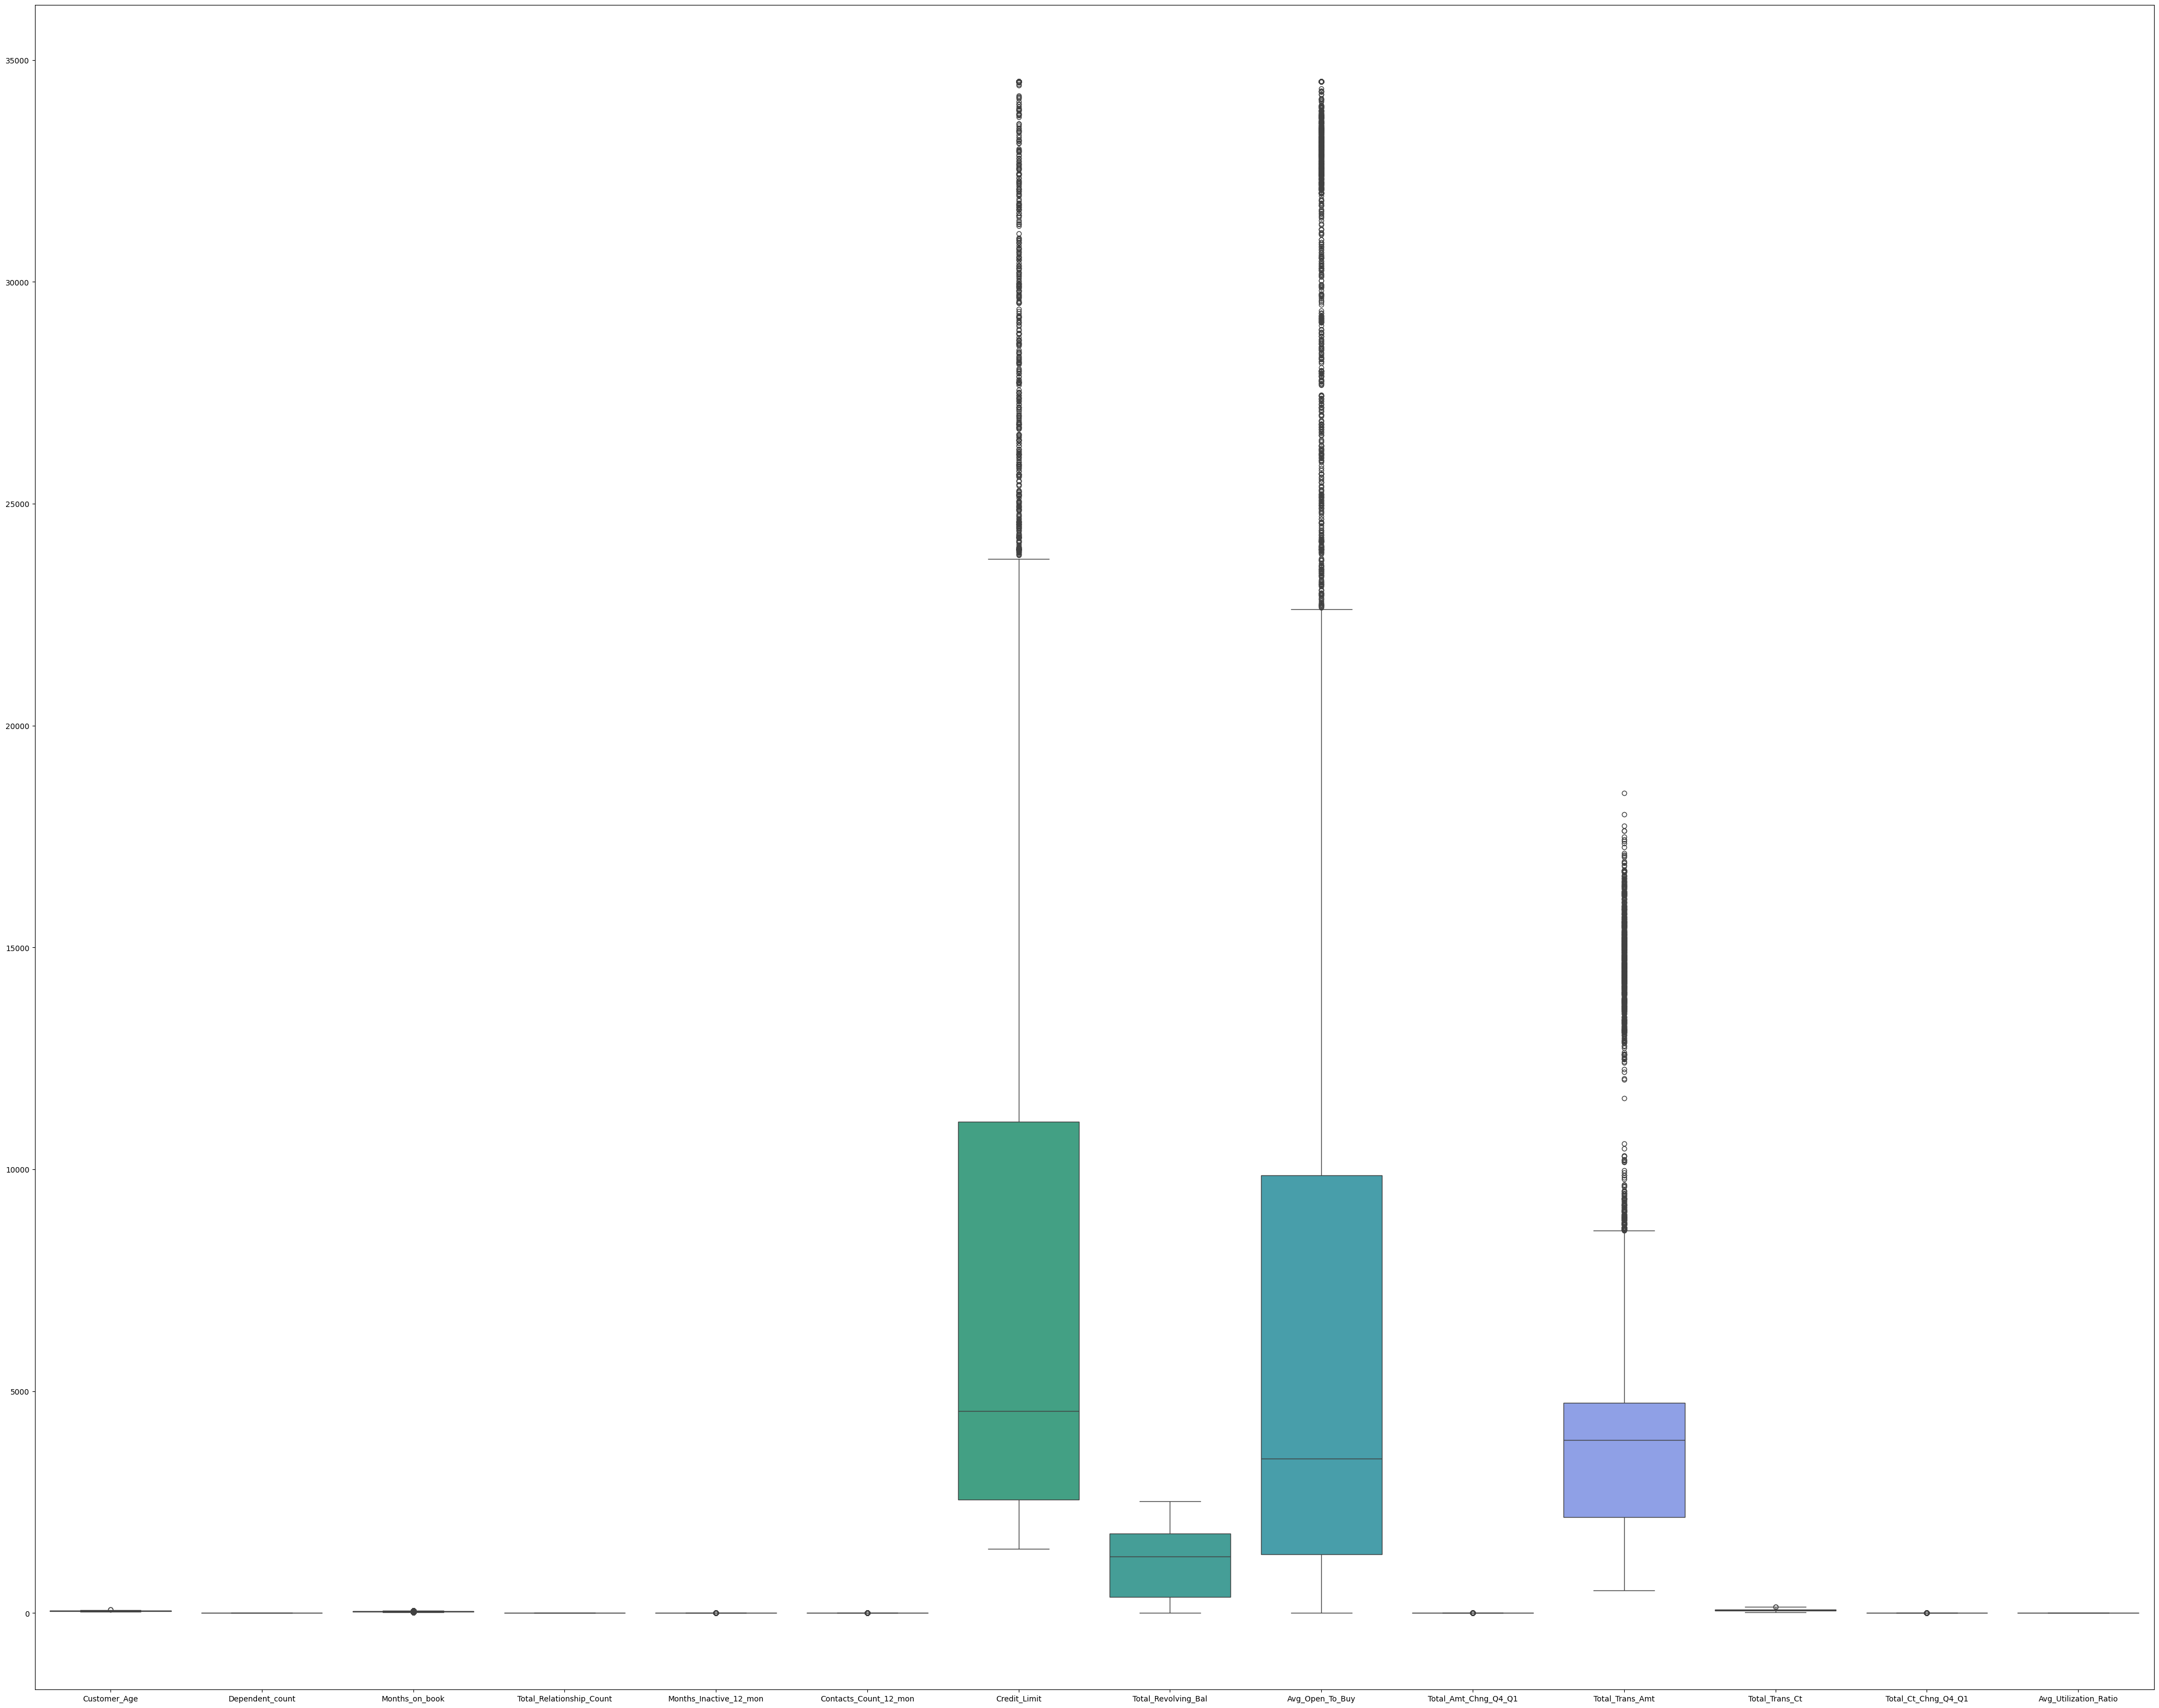

In [291]:
# print(outlier_handler.display_outliers(df))
plt.figure(figsize=(50,40))
sns.boxplot(df)

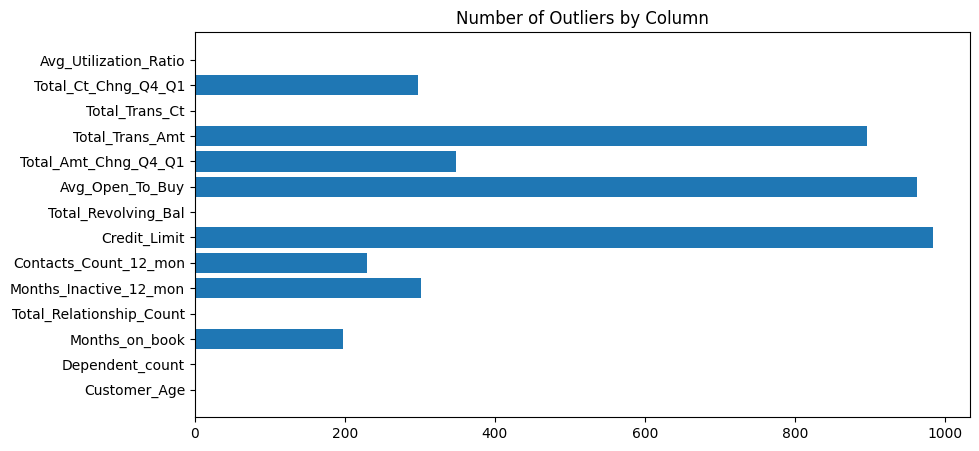

In [292]:
outlier_handler = OutlierHandling()
length_of_hs = []
length_of_ls = []
names = []


for i in df.select_dtypes('number').columns:
    higher, lower = outlier_handler.return_outliers(df[i])
    length_of_hs.append(len(higher))
    length_of_ls.append(len(lower))
    names.append(i)
    # print(f'{i}.\n\n: higher outliers : {len(higher)} \n: lower outliers: {len(lower)}\n_______\n')



# plotting
plt.figure(figsize=(10,5))
plt.barh(names, length_of_hs)
plt.title('Number of Outliers by Column')
plt.show()

In [293]:
df_cleaned = df

for i in df.select_dtypes('number').columns:
    df_cleaned[i] = outlier_handler.remove_outliers(df[i])


In [294]:
for i,j in df['Credit_Limit'].items():
    print(j)

12691.0
8256.0
3418.0
3313.0
4716.0
4010.0
nan
nan
22352.0
11656.0
6748.0
9095.0
11751.0
8547.0
2436.0
4234.0
nan
13535.0
3193.0
14470.0
20979.0
1438.3
4470.0
2492.0
12217.0
7768.0
14784.0
10215.0
10100.0
4785.0
2753.0
2451.0
8923.0
2650.0
12555.0
3520.0
3035.0
15433.0
3672.0
7882.0
nan
6205.0
17304.0
3906.0
9830.0
nan
2283.0
2548.0
19458.0
4745.0
2622.0
1438.3
3171.0
19763.0
15769.0
3298.0
2802.0
4458.0
6273.0
3336.0
3436.0
nan
5926.0
nan
14734.0
nan
6584.0
2084.0
1687.0
nan
nan
2216.0
2910.0
22913.0
nan
5272.0
7000.0
7038.0
2536.0
nan
8567.0
nan
2158.0
10133.0
nan
3085.0
19040.0
4026.0
12756.0
5266.0
9930.0
nan
6576.0
2664.0
2535.0
1709.0
3454.0
3789.0
9689.0
5449.0
23032.0
nan
2940.0
3031.0
1862.0
8358.0
nan
14450.0
1438.3
nan
8466.0
15088.0
3263.0
1494.0
13551.0
18886.0
11976.0
9964.0
nan
5362.0
nan
3174.0
12262.0
3788.0
nan
2926.0
nan
11669.0
13532.0
11888.0
2393.0
6111.0
19270.0
3710.0
3235.0
11749.0
7753.0
10408.0
3967.0
6205.0
8025.0
9036.0
14926.0
6335.0
14979.0
2732.0
2250.0


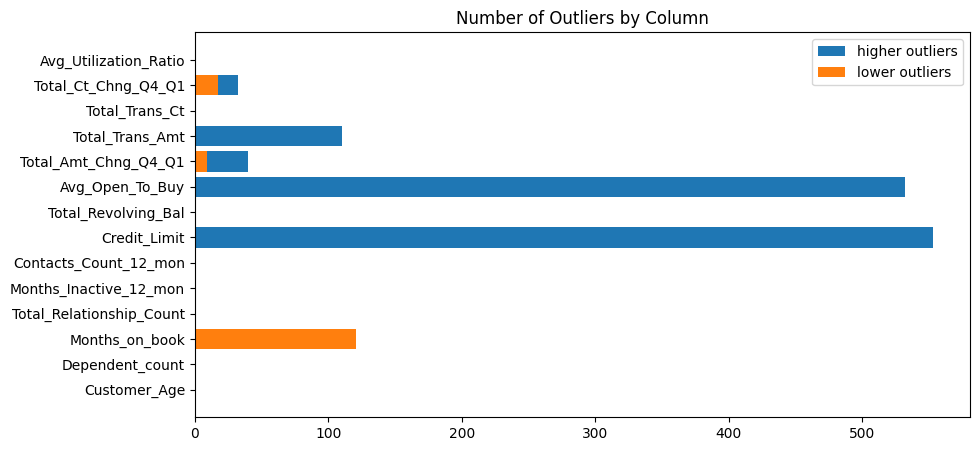

In [295]:
outlier_handler = OutlierHandling()
length_of_hs = []
length_of_ls = []
length_list = []
names = []
for i in df_cleaned.select_dtypes('number').columns:
    higher, lower = outlier_handler.return_outliers(df[i])
    length_of_hs.append(len(higher))
    length_of_ls.append(len(lower))
    length_list.append(len(lower)+len(higher))
    names.append(i)
    # print(f'{i}.\n\n: higher outliers : {len(higher)} \n: lower outliers: {len(lower)}\n_______\n')

plt.figure(figsize=(10,5))
# plt.barh(names, length_list, label='sum')
plt.barh(names, length_of_hs, label='higher outliers')
plt.barh(names, length_of_ls, label='lower outliers')
plt.title('Number of Outliers by Column')
plt.legend()
plt.show()

In [296]:
df_final = df_cleaned.copy()
df_final.dropna(inplace=True)
numeric_columns = df_cleaned.select_dtypes('number').columns.tolist()
print(numeric_columns)
df_cleaned[numeric_columns] = df_cleaned[numeric_columns].fillna(df_cleaned[numeric_columns].mean())
df_cleaned.info()

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  float64
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-

In [297]:
df_final.count()

Attrition_Flag              6799
Customer_Age                6799
Gender                      6799
Dependent_count             6799
Education_Level             6799
Marital_Status              6799
Income_Category             6799
Card_Category               6799
Months_on_book              6799
Total_Relationship_Count    6799
Months_Inactive_12_mon      6799
Contacts_Count_12_mon       6799
Credit_Limit                6799
Total_Revolving_Bal         6799
Avg_Open_To_Buy             6799
Total_Amt_Chng_Q4_Q1        6799
Total_Trans_Amt             6799
Total_Trans_Ct              6799
Total_Ct_Chng_Q4_Q1         6799
Avg_Utilization_Ratio       6799
dtype: int64

In [298]:
thing = (1,3)
type(thing)

tuple

In [299]:
newdf = pd.get_dummies(df)

In [300]:
newdf.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,45.0,3,39.0,5,1.0,3.000000,12691.0,777,11914.0,0.737494,...,False,False,True,False,False,False,True,False,False,False
1,49.0,5,44.0,6,1.0,2.000000,8256.0,864,7392.0,0.737494,...,False,False,False,False,True,False,True,False,False,False
2,51.0,3,36.0,4,1.0,2.491156,3418.0,0,3418.0,0.737494,...,False,False,False,True,False,False,True,False,False,False
3,40.0,4,34.0,3,4.0,1.000000,3313.0,2517,796.0,0.737494,...,False,False,False,False,True,False,True,False,False,False
4,40.0,3,21.0,5,1.0,2.491156,4716.0,0,4716.0,0.737494,...,False,False,True,False,False,False,True,False,False,False
